<div>
  <center>
    <h1>Rappi</h1>
    <h2>AI Engineer en Rappi 💼</h2>
    <h2>Caso Técnico: Sistema de Alertas Operacionales con AI</h2> 
    <b>Módulo: </b> módulo 1 diagnóstico. <br>
    <b>Evaluadores: </b> Eduardo Daniel Chain & Francisco Gomez.<br>
    <b>Postulante: </b> Cristian Ulises Barenca Sotelo.<br>
    <b>Correo:</b> cristian.barenca10@gmail.com<br>
  </center>
  
  <div style="text-align: right;">
    Lunes 23 de marzo del 2026, Manzanillo, Col.
  </div>
</div>    

# Módulo 1 — Diagnóstico Operacional (25%)

Analiza el dataset histórico e identifica los factores que afectan la operación. Tu análisis debe responder a estas cinco preguntas de negocio, presentadas de menor a mayor sofisticación:

1.	P1. ¿En qué horas del día y en qué zonas la operación alcanza niveles críticos de saturación? Cuantifica.
2.	P2. ¿Qué variable externa del dataset se correlaciona con el deterioro del ratio operacional? Describe el mecanismo.
3.	P3. ¿Todas las zonas responden igual a esa variable? Identifica las más vulnerables y explica por qué tienen mayor sensibilidad.
4.	P4. ¿El nivel de earnings (incentivos) está bien calibrado a lo largo del mes? ¿Detectas periodos con gasto ineficiente? Muestra los días exactos.
5.	P5. ¿Qué relación tiene el nivel de earnings con la saturación operacional? ¿Es una relación simple o depende de otras condiciones?

Nota metodológica: se evaluará no solo qué encuentras, sino cómo llegas a las conclusiones. Un número sin contexto no es un hallazgo. Una correlación sin validación de causalidad o sin control de variables confusas es una conclusión incompleta.

Entregables Módulo 1
- Notebook o script reproducible con el análisis completo (Python recomendado).
- Visualizaciones para cada hallazgo (el gráfico correcto para cada tipo de pregunta).
- Resumen de hallazgos en máximo 1 página: patrones encontrados + impacto cuantificado en la operación.


In [1]:
###############################################
# Author: Cristian U. Barenca
#
# Librerías:
#    pandas     : Manejo de DataFrames y manipulación de los datos.
#    matplotlib : Visualización de gráficos.
#    seaborn    : Creación de gráficos estadísticos.
#    
# Comando:
#   pip install pandas openpyxl seaborn matplotlib
#
# Version:
#    v1.0 - Creación del ejercicio completo.
#    Fecha: 24 de marzo de 2025
###############################################

#Importamos las librerías necesarias para el desarrollo de la actividad.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.discrete.discrete_model as sdd

In [2]:
# Cargamos el dataset de Excel en un DataFrame de pandas
# Archivo: "rappi_delivery_case_data.xlsx", hoja: "RAW_DATA"
df = pd.read_excel("../rappi_delivery_case_data.xlsx",sheet_name="RAW_DATA",engine="openpyxl")

# Definimo la metrica de oferta/demanda
df["RATIO"] = df["ORDERS"] / df["CONNECTED_RT"]

# Misma variable en categorización
df["RATIO_CATEGORY"] = pd.cut(df["RATIO"], bins=[-0.1,0.5,0.9,1.2,1.8,np.inf], labels=["Sobre-oferta","Sobre-oferta-baja", "Rango-saludable", "Saturacion-baja","Saturacion"])

#Intervalos de categorización
# < 0.5: Sobre-oferta (ineficiencia de costo)    
# 0.6 a 0.8 : Sobre-oferta-baja
# 0.9 – 1.2: Rango saludable
# 1.3 - 1.7: Saturación-baja
# > 1.8: Saturacion (pérdida de órdenes)

# Mostramos las primeras 5 filas del DataFrame para verificar la carga y estructura de los datos
df.head(5)

,COUNTRY,DATE,HOUR,CITY,ZONE,CONNECTED_RT,ORDERS,EARNINGS,PRECIPITATION_MM,RATIO,RATIO_CATEGORY
0,Mexico,2024-03-01,0,Monterrey,Centro,6,2,54.4,0.0,0.333333,Sobre-oferta
1,Mexico,2024-03-01,0,Monterrey,Mitras Centro,5,1,52.4,0.0,0.200000,Sobre-oferta
2,Mexico,2024-03-01,0,Monterrey,Apodaca Centro,4,1,59.1,0.0,0.250000,Sobre-oferta
3,Mexico,2024-03-01,0,Monterrey,Escobedo,3,1,53.3,0.0,0.333333,Sobre-oferta
4,Mexico,2024-03-01,0,Monterrey,Carretera Nacional,2,0,55.0,0.0,0.000000,Sobre-oferta


# Pre - work

## Análisis Exploratorio de Datos (EDA) 

Objetivo: Ayuda a entender la distribución de los datos, identificar valores atípicos (outliers), detectar valores faltantes y descubrir patrones iniciales.

Por lo tanto, esto nos permite conocer la estructura del dataset y planear los análisis posteriores.

### Revisar estructura y datos

In [3]:
# Verificamos el tipo de datos de cada columna y la cantidad de valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   COUNTRY           10080 non-null  str     
 1   DATE              10080 non-null  str     
 2   HOUR              10080 non-null  int64   
 3   CITY              10080 non-null  str     
 4   ZONE              10080 non-null  str     
 5   CONNECTED_RT      10080 non-null  int64   
 6   ORDERS            10080 non-null  int64   
 7   EARNINGS          10080 non-null  float64 
 8   PRECIPITATION_MM  10080 non-null  float64 
 9   RATIO             10080 non-null  float64 
 10  RATIO_CATEGORY    10080 non-null  category
dtypes: category(1), float64(3), int64(3), str(4)
memory usage: 797.7 KB


Esto nos permite identificar columnas numéricas, categóricas y posibles valores faltantes
Información general del DataFrame:
 - Filas: 10,080
 - Columnas: 9
 - Tipos de datos:
     * str    : COUNTRY, DATE, CITY, ZONE
     * int64  : HOUR, CONNECTED_RT, ORDERS
     * float64: EARNINGS, PRECIPITATION_MM, RATIO 
     * category: RATIO_CATEGORY
 - No hay valores nulos en ninguna columna.

In [4]:
# Generamos estadísticas descriptivas de las columnas numéricas del DataFrame
# Esto incluye: conteo, media, desviación estándar, valores mínimo y máximo,
# y los percentiles (25%, 50%, 75%). Nos ayuda a entender la distribución 
# y rangos de los datos antes de realizar análisis más profundos.
df.describe()

,HOUR,CONNECTED_RT,ORDERS,EARNINGS,PRECIPITATION_MM,RATIO
count,10080.00000,10080.00000,10080.000000,10080.000000,10080.000000,10080.000000
mean,11.50000,9.14256,9.440278,57.696081,0.246667,0.817924
std,6.92253,7.65022,10.611813,8.292825,1.265046,0.550939
min,0.00000,1.00000,0.000000,49.000000,0.000000,0.000000
25%,5.75000,3.00000,1.000000,52.400000,0.000000,0.500000
50%,11.50000,7.00000,6.000000,55.600000,0.000000,0.800000
75%,17.25000,13.00000,14.000000,58.700000,0.000000,1.096774
max,23.00000,46.00000,57.000000,97.000000,10.300000,5.666667


Estas estadísticas ayudan a entender la distribución, detectar posibles valores atípicos y planificar análisis o visualizaciones posteriores.

 - HOUR: valores de 0 a 23, media 11.5, distribución uniforme a lo largo del día.
 - CONNECTED_RT: promedio ~9, máximo 46, indica cantidad de repartidores conectados.
 - ORDERS: promedio ~9.4, máximo 57, muestra dispersión alta en pedidos por hora.
 - EARNINGS: promedio ~57.7, rango 49-97, ingresos por hora relativamente consistentes.
 - PRECIPITATION_MM: mayoría de valores en 0, máximo 10.3 mm, indica pocas lluvias.
 - RATIO: En promedio es 0.8 y hay una Sobre oferta baja.



In [5]:
# =====================================================================
# Visualización de valores unicos
# =====================================================================
# Objetivo:
#   Identificar valores únicos y su frecuencia.
#   Detectar inconsistencias o posibles errores.
#   Tomar decisiones de limpieza y normalización de los datos antes de análisis posteriores.

# Definimos las columnas del DataFrame a analizar
columnas = ["COUNTRY", "DATE", "HOUR", "CITY", "ZONE", "CONNECTED_RT", "ORDERS", "EARNINGS", "PRECIPITATION_MM", "RATIO_CATEGORY"]

# Recorremos cada columna para obtener estadísticas básicas de frecuencia
# - Total de registros por columna.
# - Número de valores únicos.
# - Conteo de ocurrencias de cada valor.
for col in columnas:
    conteos = df[col].value_counts()
      
    # Encabezado con información general de la columna
    print(f"\nPara la variable {col}:")
    print(f"  - Total de registros: {len(df[col])}")
    print(f"  - Valores únicos: {len(conteos)}\n")

    # Detalle de cuántas veces aparece cada valor
    for val, cant in conteos.items():
        print(f"    - {val}: {cant} vez/veces")


Para la variable COUNTRY:
  - Total de registros: 10080
  - Valores únicos: 1

    - Mexico: 10080 vez/veces

Para la variable DATE:
  - Total de registros: 10080
  - Valores únicos: 30

    - 2024-03-01: 336 vez/veces
    - 2024-03-02: 336 vez/veces
    - 2024-03-03: 336 vez/veces
    - 2024-03-04: 336 vez/veces
    - 2024-03-05: 336 vez/veces
    - 2024-03-06: 336 vez/veces
    - 2024-03-07: 336 vez/veces
    - 2024-03-08: 336 vez/veces
    - 2024-03-09: 336 vez/veces
    - 2024-03-10: 336 vez/veces
    - 2024-03-11: 336 vez/veces
    - 2024-03-12: 336 vez/veces
    - 2024-03-13: 336 vez/veces
    - 2024-03-14: 336 vez/veces
    - 2024-03-15: 336 vez/veces
    - 2024-03-16: 336 vez/veces
    - 2024-03-17: 336 vez/veces
    - 2024-03-18: 336 vez/veces
    - 2024-03-19: 336 vez/veces
    - 2024-03-20: 336 vez/veces
    - 2024-03-21: 336 vez/veces
    - 2024-03-22: 336 vez/veces
    - 2024-03-23: 336 vez/veces
    - 2024-03-24: 336 vez/veces
    - 2024-03-25: 336 vez/veces
    - 2024-0

Muchas columnas pueden contener datos en formatos distintos, inconsistentes o con errores tipográficos.

Por ejemplo:
- Países escritos con diferentes mayúsculas: "Colombia" vs "COLOMBIA".
- Zonas horarias o ciudades con nombres duplicados o mal escritos.

Este análisis permite:
1. Identificar valores únicos y su frecuencia.
2. Detectar inconsistencias o posibles errores.
3. Tomar decisiones de limpieza y normalización de los datos antes de análisis posteriores.

# Análisis de variables categóricas

C:\Users\ulise\AppData\Local\Temp\ipykernel_7936\1117771792.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


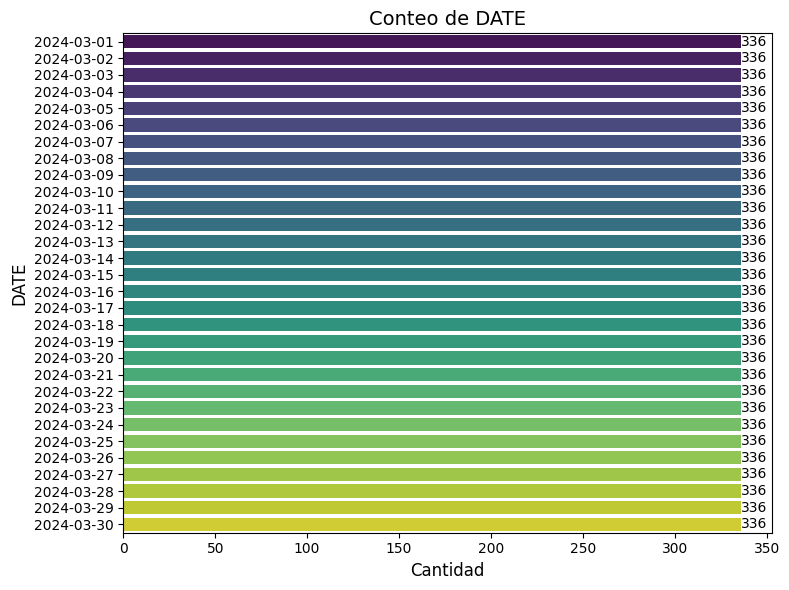

C:\Users\ulise\AppData\Local\Temp\ipykernel_7936\1117771792.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


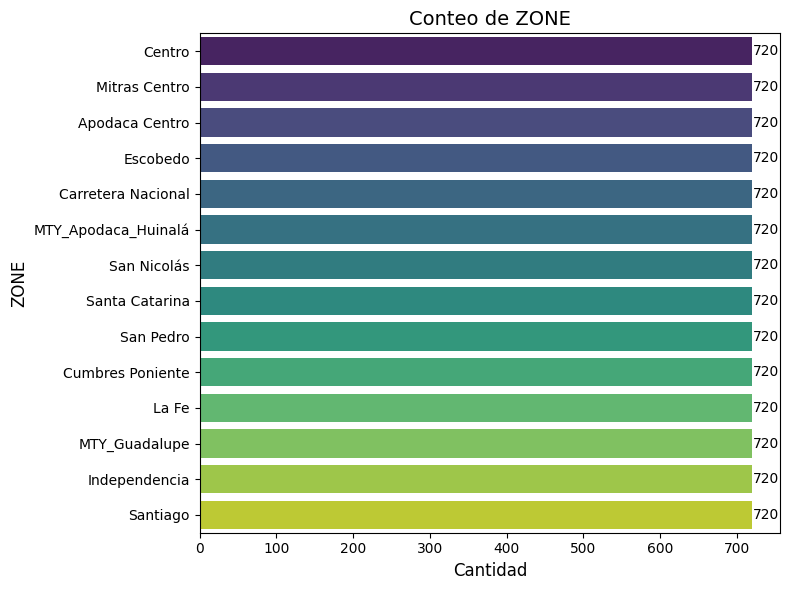

C:\Users\ulise\AppData\Local\Temp\ipykernel_7936\1117771792.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


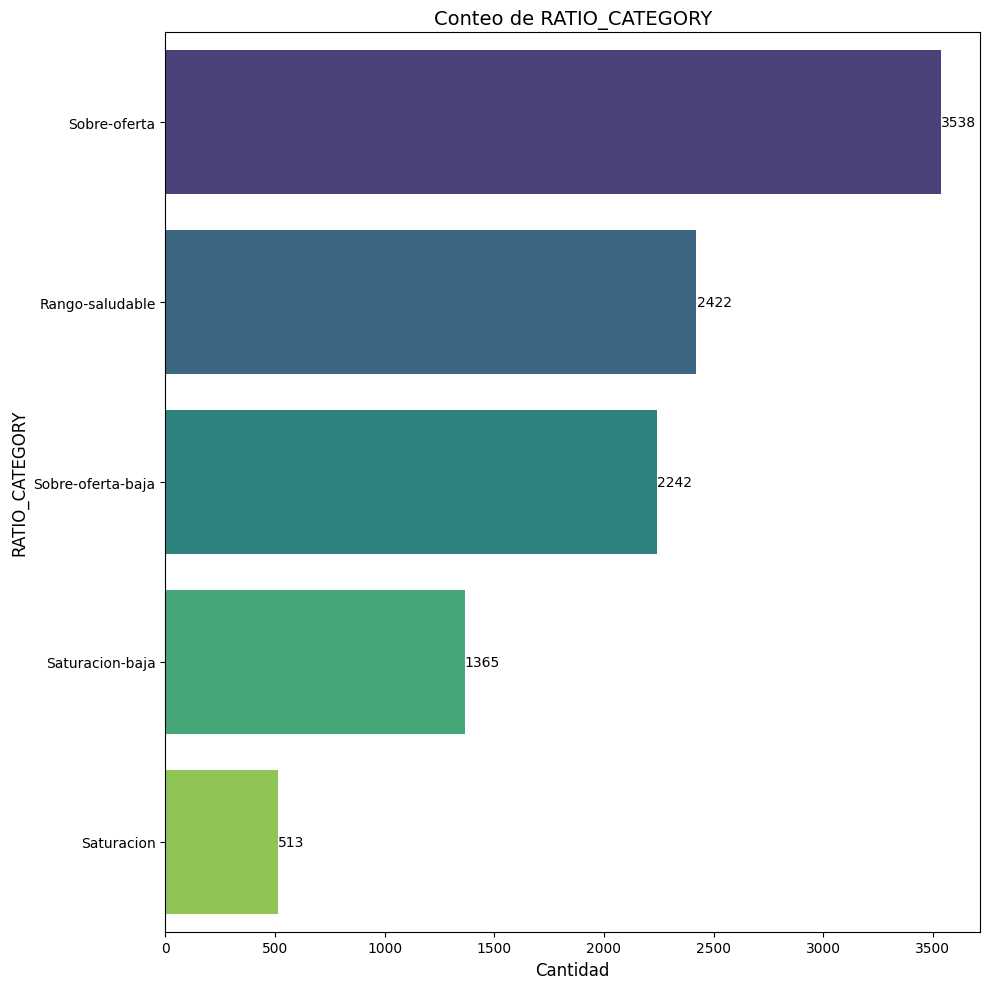

In [6]:
# =====================================================================
# Visualización de variables categóricas
# =====================================================================
# Objetivo:
#   Analizar la distribución de las categorías en las columnas 'DATE','ZONE' y 'RATIO_CATEGORY'.
#   Esto permite identificar las categorías más frecuentes y posibles irregularidades.

# Lista de columnas categóricas
categorical_cols = ['DATE', 'ZONE', 'RATIO_CATEGORY']

# Generación de gráficos de conteo para cada columna categórica
for col in categorical_cols:
    
    # Ajuste dinámico del tamaño
    if col == 'RATIO_CATEGORY':
        plt.figure(figsize=(10, 10))  # más alto
    else:
        plt.figure(figsize=(8, 6))
    
    top_categories = df[col].value_counts().index

    ax = sns.countplot(
        data=df,
        y=col,
        order=top_categories,
        palette="viridis"
    )

    ax.set_title(f'Conteo de {col}', fontsize=14)
    ax.set_xlabel('Cantidad', fontsize=12)
    ax.set_ylabel(col, fontsize=12)

    # Agregar etiquetas de cantidad
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width + 0.1, p.get_y() + p.get_height()/2, int(width), va='center')

    plt.tight_layout()

    # Guardar la figura con el nombre de la columna
    plt.savefig(f'Visualizaciones para cada hallazgo/EDA/1.Variables_categóricas_conteo_{col}.png', dpi=300)  # dpi=300 para mejor resolución

    # Mostramos en el notebook
    plt.show()

El dataset, en cuanto a sus variables categóricas, presenta una distribución equilibrada, ya que no se observan concentraciones excesivas en una sola categoría, lo que favorece un análisis más representativo.

* En marzo hay 336 registros, lo que representa la cantidad de datos en ese periodo de tiempo.
* Sin embargo, cuando analizamos las 14 zonas de Monterrey, encontramos 720 registros, ya que cada zona tiene múltiples datos en diferentes momentos.

# Análisis de variables numérica

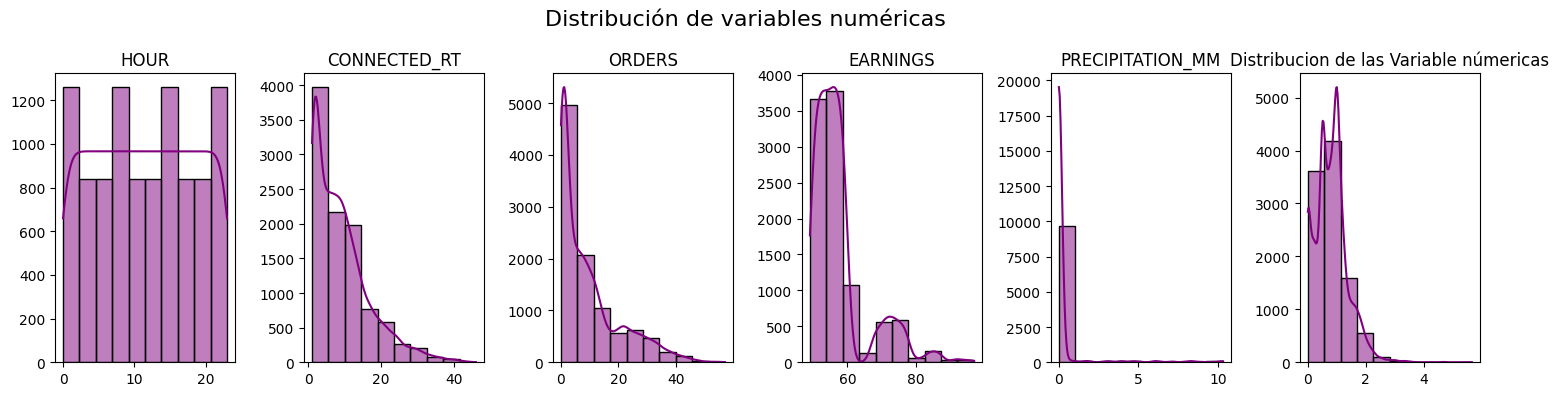

In [7]:
# =====================================================================
# Visualización de variables numéricas
# =====================================================================
# Objetivo:
#   Analizar la distribución de las variables numéricas mediante histogramas
#   y estimaciones de densidad (KDE), lo que permite identificar patrones,
#   sesgos y posibles valores atípicos.

# Lista de columnas numéricas a analizar
numerical_cols = ["HOUR", "CONNECTED_RT", "ORDERS", "EARNINGS", "PRECIPITATION_MM", "RATIO"]

# Configuración de subgráficos (1 fila, múltiples columnas)
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 4))

# Aseguramos que 'axes' sea iterable en caso de una sola variable
if len(numerical_cols) == 1:
    axes = [axes]

# Generación de histogramas con curva de densidad (KDE)
for i, col in enumerate(numerical_cols):

    # Configuración de títulos y etiquetas
    sns.histplot(df[col], bins=10, kde=True, color='purple', ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Definimos el Título general correcto
fig.suptitle("Distribución de variables numéricas", fontsize=16)

# Ajustamos del layout (dejando espacio para el título)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Ajuste del layout y visualización final
plt.title("Distribucion de las Variable númericas")
plt.tight_layout()
plt.savefig(f'Visualizaciones para cada hallazgo/EDA/2.Variables_numéricas_conteo_{col}.png', dpi=300)
plt.show()

Se realizaron histogramas para las variables numéricas con el fin de analizar su distribución. Esto permite identificar la forma de los datos, posibles sesgos y la presencia de valores atípicos, lo cual es fundamental antes de realizar análisis más avanzados.

**Resumen de las distribuciones**

|Variable | Tipo de Distribución|Interpretación Rápida|
|---|---|---|
|HOUR|Uniforme|Los datos cubren las 24 horas del día de forma equilibrada.|
|CONNECTED_RT|Sesgada a la derecha|La mayoría pasa poco tiempo conectado, pocos repartidores tienen jornadas largas.|
|ORDERS	|Sesgada a la derecha|La gran mayoría de los registros tienen pocos pedidos (0-10).|
|EARNINGS|Multimodal / Bimodal|Hay dos grupos claros de ingresos: uno bajo (55) y uno medio (75).|
|PRECIPITATION|Concentrada en cero|Casi no hay registros con lluvia, la mayoría son días secos.|
|RATIO|Sesgada a la derecha | Hay muchos registros con ratio por debajo de 1 corresponden a las categorias: Sobre-oferta (ineficiencia de costo), Sobre-oferta-baja y Rango saludable|

# Correlaciones

                      HOUR  EARNINGS  PRECIPITATION_MM     RATIO
HOUR              1.000000  0.256077          0.164022  0.448745
EARNINGS          0.256077  1.000000          0.226029  0.099885
PRECIPITATION_MM  0.164022  0.226029          1.000000  0.318902
RATIO             0.448745  0.099885          0.318902  1.000000


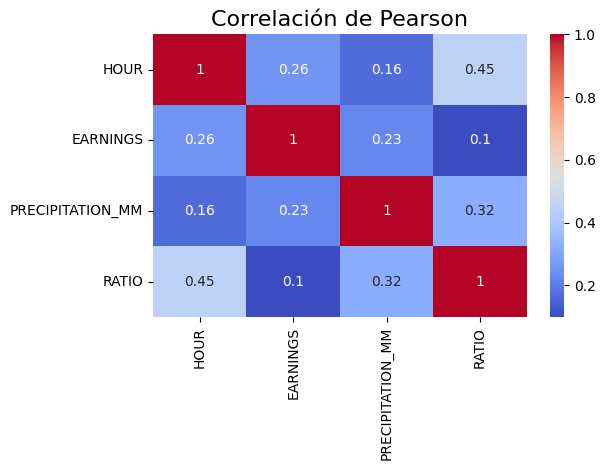

In [8]:
# =====================================================================
# Análisis de correlación entre variables numéricas
# =====================================================================
# Objetivo:
#   Evaluar la relación lineal (Pearson) entre las variables numéricas del dataset.
#   Esto permite identificar si existe dependencia entre variables,
#   lo cual es útil para detectar patrones y apoyar la toma de decisiones.
# Se omote Orders y Connected por que ya fueron combinadas en radio

# Cálculo de la matriz de correlación
corr =  df[["HOUR","EARNINGS", "PRECIPITATION_MM", "RATIO"]].corr()

# Mostramos la matriz de correlación en formato tabular
print(corr)

# Visualización de la matriz mediante un mapa de calor (heatmap)
# Los valores cercanos a 1 indican correlación positiva fuerte,
# cercanos a -1 correlación negativa, y cercanos a 0 poca o nula relación
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Definimos el Título general correcto
plt.title("Correlación de Pearson", fontsize=16)
# Ajuste del layout y visualización final
plt.tight_layout()
# Guardamos el análisis de correlación de Pearson
plt.savefig(f'Visualizaciones para cada hallazgo/EDA/3.Correlacion_Pearson.png', dpi=300)  # dpi=300 para mejor resolución
# Mostramos el gráfico
plt.show()

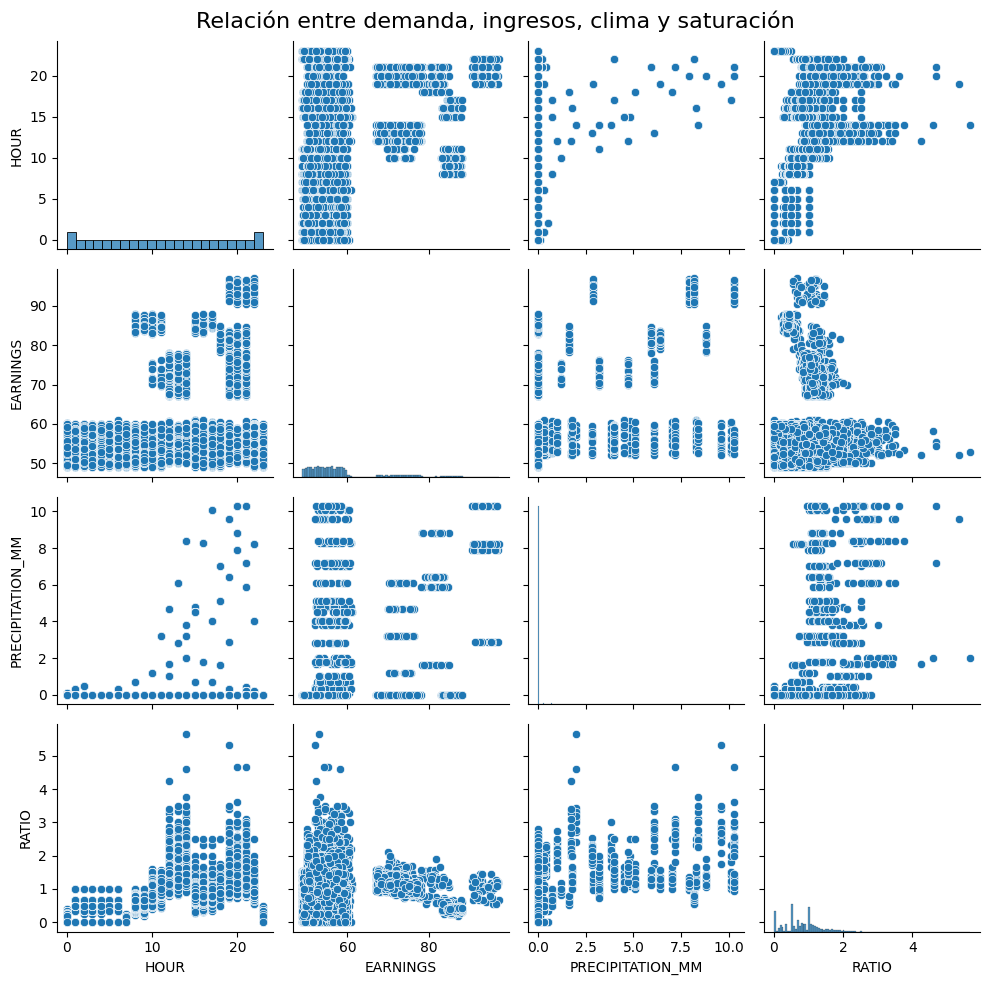

In [9]:
# Visualizar la correlación
# Seleccionamos las variables númericas
vars_to_plot = ["HOUR", "EARNINGS", "PRECIPITATION_MM", "RATIO"]

# Matriz de scatter plots
g = sns.pairplot(df[vars_to_plot])

# Definimos el Título
g.fig.suptitle("Relación entre demanda, ingresos, clima y saturación", fontsize=16)

# Ajuste del layout y visualización final
plt.tight_layout()
# Guardamos la correlación visual
plt.savefig(f'Visualizaciones para cada hallazgo/EDA/4.Correlacion_en_visual.png', dpi=300)
plt.show()

### Conclusion

**Correlación**
* Vimo que la Conexión (Connected_RT) y las Órdenes tienen una relación del 89%. Esto nos dice que son casi "espejos": si una sube, la otra sube casi siempre.

* En cambio, la Lluvia (PRECIPITATION_MM) y las Órdenes (ORDERS) tienen una relación más baja (23%) a simple vista, pero cuando las analizamos en conjunto con otras variables, su importancia real aparece.

**El Modelo de Predicción (Regresión OLS)**: De cada 10 órdenes que recibimos, nuestro modelo el R² explica por qué llegaron 8 de ellas. Solo un 20% depende de factores externos que no podemos medir aún (como promociones de la competencia o fallas en la app).

**Coeficientes**
* Por Conexión: Por cada repartidor/unidad extra conectada, ganamos 1.18 órdenes. Es nuestra palanca más fuerte.
* Por Clima: Confirmamos que la lluvia no es un estorbo, sino un motor. Cada milímetro de lluvia nos genera casi 1 orden extra (0.95). Esto valida que el cliente pide más cuando no quiere salir.

**La Prueba de Calidad (Durbin-Watson y P-values)**
Todos los factores que presento tienen un 'margen de error' cercano a cero (P>|t| es 0.000), lo cual sustenta este trabajo.

In [10]:
# Regresion Logistica Multiclase
model = sdd.MNLogit(data=df, endog=df["RATIO_CATEGORY"], exog=df[["HOUR","PRECIPITATION_MM","EARNINGS"]]).fit()
model.summary()

c:\ProgramData\anaconda3\envs\rappi_ai_project_py311\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['data']
  warnings.warn(msg, ValueWarning)


Optimization terminated successfully.
         Current function value: 1.269724
         Iterations 10


c:\ProgramData\anaconda3\envs\rappi_ai_project_py311\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['data']
  warnings.warn(msg, ValueWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:         RATIO_CATEGORY   No. Observations:                10080
Model:                        MNLogit   Df Residuals:                    10068
Method:                           MLE   Df Model:                            8
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.1343
Time:                        06:07:13   Log-Likelihood:                -12799.
converged:                       True   LL-Null:                       -14785.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=============================================================================================
RATIO_CATEGORY=Sobre-oferta-baja       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
HOUR                                 0.2167      0.006     39.375      0.000       0.206       0.228
PRECIPITATION_MM                     1.5686      0.318      4.932      0.000       0.945       2.192
EARNINGS                            -0.0467      0.001    -40.689      0.000      -0.049      -0.044
----------------------------------------------------------------------------------------------------
RATIO_CATEGORY=Rango-saludable       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
HOUR                               0.1784      0.005     34.465      0.000       0.168       0.189
PRECIPITATION_MM                   1.7451      0.317      5.503      0.000       1.124       2.367
EARNINGS                          -0.0358      0.001    -35.573      0.000      -0.038      -0.034
--------------------------------------------------------------------------------------------------
RATIO_CATEGORY=Saturacion-baja       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
HOUR                               0.2475      0.006     38.703      0.000       0.235       0.260
PRECIPITATION_MM                   1.9878      0.317      6.265      0.000       1.366       2.610
EARNINGS                          -0.0641      0.001    -42.869      0.000      -0.067      -0.061
--------------------------------------------------------------------------------------------------
RATIO_CATEGORY=Saturacion       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
HOUR                          0.2807      0.010     28.906      0.000       0.262       0.300
PRECIPITATION_MM              2.1608      0.318      6.805      0.000       1.538       2.783
EARNINGS                     -0.0952      0.003    -35.091      0.000      -0.101      -0.090
=============================================================================================
"""

Aparentemente todas las variables estan proporcionando informacion PRECIPITATION_MM, EARNINGS y HOUR ya que pasan la prueba de hipotesis.

Prueba de hipotesis Z, Evaluamos si el coeficiente asociado a las variables es diferente de cero. 

**Futuro** - Aplicar Regresion logistica de Sickit-learn desde el punto de vista de Machine Learning, ya utilizando valores de entrenamiento y prueba.

# Entregable 

Debemos mirar primero la correlación global entre EARNINGS y SATURATION

### P1. ¿En qué horas del día y en qué zonas la operación alcanza niveles críticos de saturación? Cuantifica.

Se define saturación como aquellos momentos en los que la demanda (ORDERS) supera significativamente la oferta disponible (CONNECTED_RT), lo cual puede medirse mediante la relación entre pedidos y repartidores.

El sistema opera bajo saturación crítica el 5.09% del tiempo.


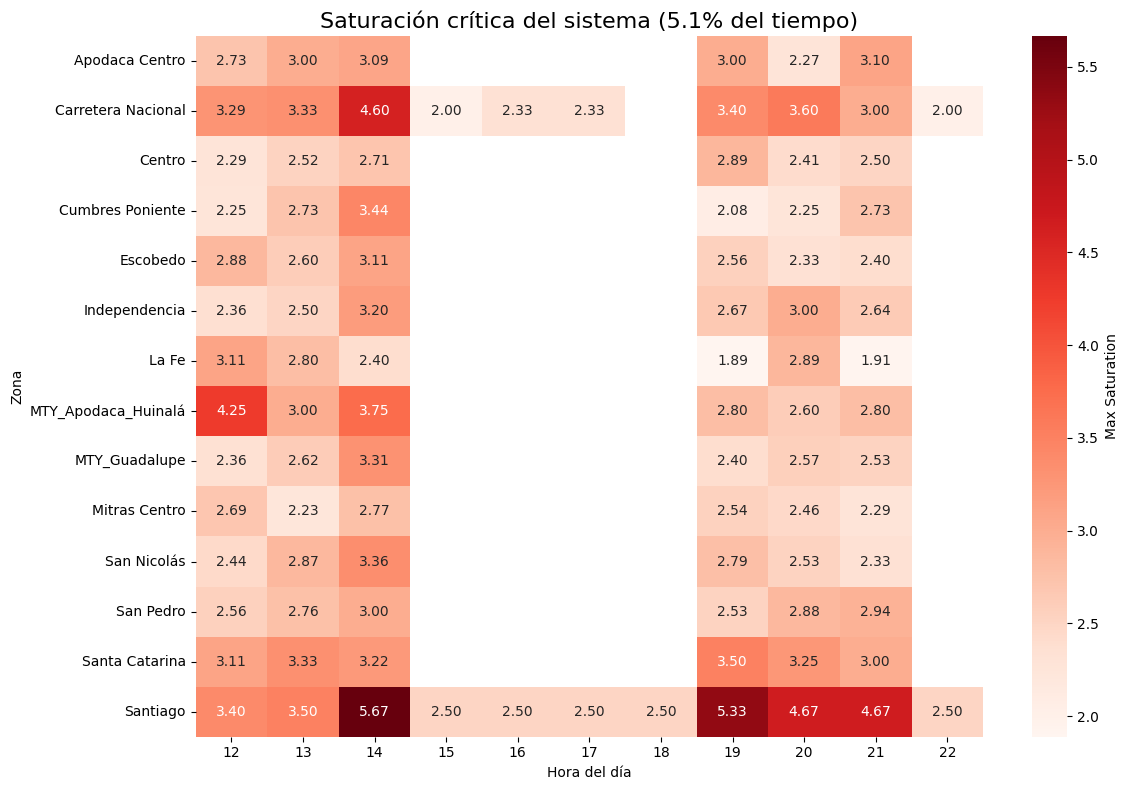

In [11]:
# Agregamos una columna de saturación
df['SATURATION'] = df['ORDERS'] / df['CONNECTED_RT']

# Agrupamos por HOUR y ZONE
saturation_summary = df.groupby(['HOUR', 'ZONE']).agg(
    mean_saturation=('SATURATION', 'mean'),
    max_saturation=('SATURATION', 'max'),
    hours_count=('SATURATION', 'count'),
    critical_hours=('SATURATION', lambda x: (x > 1.8).sum())
).reset_index()

saturation_summary = saturation_summary.sort_values(by=['critical_hours', 'max_saturation'], ascending=False)

# Filtrar las filas donde la saturación máxima supera 1.8
critical_saturation = saturation_summary[saturation_summary['max_saturation'] > 1.8]


# Calculamos el porcentaje en el que el sistema opera bajo saturación critica
total_horas_operadas = len(df)
horas_en_colapso = df[df['SATURATION'] > 1.8].shape[0]
porcentaje_critico = (horas_en_colapso / total_horas_operadas) * 100
print(f"El sistema opera bajo saturación crítica el {porcentaje_critico:.2f}% del tiempo.")

# Pivotamos los datos para tener HOUR como filas y ZONE como columnas
heatmap_data = critical_saturation.pivot(index='ZONE', columns='HOUR', values='max_saturation', )

# Crear el heatmap
plt.figure(figsize=(12, 8))
plt.title(f"Saturación crítica del sistema ({porcentaje_critico:.1f}% del tiempo)", fontsize=16)
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Reds", cbar_kws={'label': 'Max Saturation'})
plt.ylabel("Zona")
plt.xlabel("Hora del día")

# Guardamos el Heatmap de saturación crítica por hora y zona (>1.8)
plt.tight_layout()
plt.savefig("Visualizaciones para cada hallazgo/P1/P1_heatmap_saturacion_critica_mayor_1_8.png",dpi=300)
plt.show()

Respuesta: 

La operación alcanza niveles críticos de saturación principalmente durante dos franjas horarias: 

El sistema opera bajo saturación crítica el 5.09% del tiempo.

Entre las **12:00** y las **14:00**, coincidiendo con el **pico de la comida**, cuando **casi todas las zonas presentan saturación** crítica con niveles superiores a 3.0. 

Asimismo: Entre las **19:00** y las **21:00**, en el pico nocturno, cuando la saturación regresa de manera selectiva **afectando** principalmente a **Santiago**, **Carretera Nacional** y **Santa Catarina**. 

En cambio: Entre las **15:00** y las **18:00**, la mayoría de las zonas operan con normalidad o baja demanda, excepto **Santiago** y **Carretera Nacional**, que **mantienen actividad moderada**. 

Imporante
* Santa Catarina presenta saturación elevada en el pico nocturno, mientras que Carretera Nacional requiere atención menor. 
* Se recomienda reforzar recursos durante los picos críticos y aprovechar las franjas de baja demanda para redistribución de personal o mantenimiento operativo.
* La zona de Santiago es la más problemática, con niveles críticos sostenidos durante gran parte del día, lo que sugiere una necesidad urgente de aumentar la capacidad de repartidores.


### P2. ¿Qué variable externa del dataset se correlaciona con el deterioro del ratio operacional? Describe el mecanismo.


Promedio de saturación por hora:
 HOUR
14    1.596144
13    1.525285
12    1.520648
21    1.395798
19    1.366347
20    1.361651
11    1.069834
10    1.039233
22    0.993293
18    0.845851
17    0.838198
16    0.823652
15    0.822682
8     0.612786
9     0.600171
4     0.470040
6     0.463492
5     0.462698
1     0.461508
2     0.461508
3     0.441071
23    0.180008
0     0.170051
7     0.108225
Name: SATURATION, dtype: float64

Promedio de saturación por zona:
 ZONE
Santa Catarina         0.921062
Apodaca Centro         0.869798
Independencia          0.868651
Escobedo               0.857836
La Fe                  0.855743
Centro                 0.846878
Cumbres Poniente       0.842194
Mitras Centro          0.836515
MTY_Guadalupe          0.834492
San Pedro              0.828550
San Nicolás            0.825907
Carretera Nacional     0.706400
Santiago               0.695677
MTY_Apodaca_Huinalá    0.661233
Name: SATURATION, dtype: float64
Correlación Saturación vs Lluvia: 0.3189


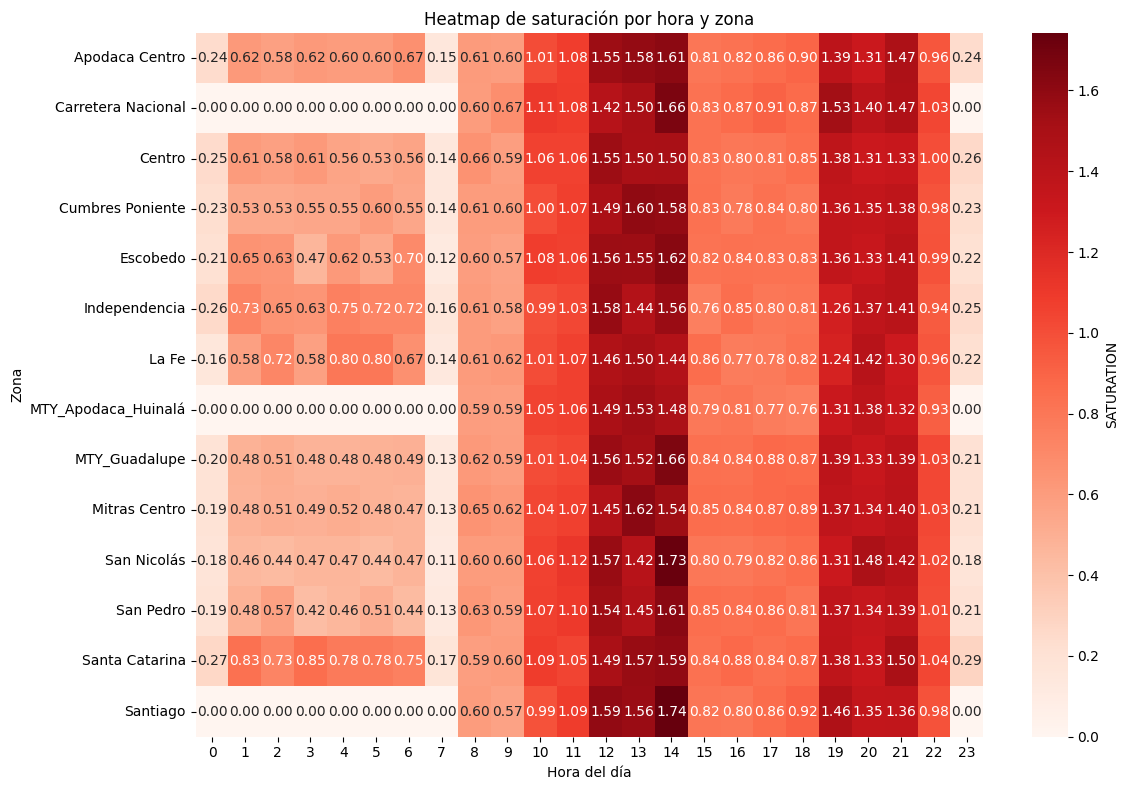

In [12]:
# 1. Promedio de saturación por HOUR
hour_avg = df.groupby('HOUR')['SATURATION'].mean().sort_values(ascending=False)
print("\nPromedio de saturación por hora:\n", hour_avg)

# 2. Promedio de saturación por ZONE
zone_avg = df.groupby('ZONE')['SATURATION'].mean().sort_values(ascending=False)
print("\nPromedio de saturación por zona:\n", zone_avg)

ext_corr = df['SATURATION'].corr(df['PRECIPITATION_MM'])
print(f"Correlación Saturación vs Lluvia: {ext_corr:.4f}")

# 4. Visualización Heatmap HOUR vs ZONE
heatmap_data = df.pivot_table(index='ZONE', columns='HOUR', values='SATURATION', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Reds", cbar_kws={'label': 'SATURATION'})
plt.title("Heatmap de saturación por hora y zona")
plt.ylabel("Zona")
plt.xlabel("Hora del día")

# Guardamos el Heatmap de saturación crítica por hora y zona (>1.8)
plt.tight_layout()
plt.savefig("Visualizaciones para cada hallazgo/P2/Heatmap_de_saturación_por_hora_y_zona.png",dpi=300)
plt.show()

In [13]:
# 1. Definimos los grupos (Seco vs Lluvioso)
df['IS_RAINING'] = df['PRECIPITATION_MM'] > 0

# 2. Calculamos la saturación promedio por zona para ambos escenarios
comparativo = df.groupby(['ZONE', 'IS_RAINING'])['SATURATION'].mean().unstack()

# 3. Renombramos columnas para claridad
comparativo.columns = ['Saturacion_Seco', 'Saturacion_Lluvia']

# 4. Calculamos el % de Incremento porcentual de la saturación
comparativo['Incremento_saturacion_%'] = ((comparativo['Saturacion_Lluvia'] / comparativo['Saturacion_Seco']) - 1) * 100

# Ordenamos por las zonas que más sufren el impacto
comparativo = comparativo.sort_values(by='Incremento_saturacion_%', ascending=False)

print("--- IMPACTO DE LA LLUVIA EN EL RATIO OPERACIONAL POR ZONA ---")
print(comparativo.round(2))

--- IMPACTO DE LA LLUVIA EN EL RATIO OPERACIONAL POR ZONA ---
                     Saturacion_Seco  Saturacion_Lluvia  \
ZONE                                                      
Santiago                        0.62               1.90   
Carretera Nacional              0.64               1.70   
MTY_Apodaca_Huinalá             0.61               1.39   
Santa Catarina                  0.88               1.60   
San Pedro                       0.79               1.42   
MTY_Guadalupe                   0.80               1.42   
San Nicolás                     0.79               1.39   
Escobedo                        0.82               1.44   
Independencia                   0.83               1.46   
Cumbres Poniente                0.81               1.39   
Centro                          0.81               1.39   
Mitras Centro                   0.80               1.38   
Apodaca Centro                  0.83               1.42   
La Fe                           0.82               1.

**Respuesta**

Si bien el aumento de Órdenes es lo que dispara directamente el ratio de saturación (efecto matemático), la variable externa que actúa como el principal detonante del deterioro operacional es la Lluvia.

El mecanismo es el siguiente: la lluvia genera un pico de demanda repentino que nuestra red de Repartidores Conectados no puede absorber a la misma velocidad, elevando la saturación un 69.52% por encima de los niveles normales y rompiendo la eficiencia del sistema.

### P3. ¿Todas las zonas responden igual a esa variable? Identifica las más vulnerables y explica por qué tienen mayor sensibilidad.

Estadísticas por zona:
                    ZONE  mean_saturation  max_saturation  critical_hours  \
12       Santa Catarina         0.921062        3.500000              38   
0        Apodaca Centro         0.869798        3.100000              37   
5         Independencia         0.868651        3.200000              38   
4              Escobedo         0.857836        3.111111              36   
6                 La Fe         0.855743        3.111111              26   
2                Centro         0.846878        2.888889              35   
3      Cumbres Poniente         0.842194        3.444444              30   
9         Mitras Centro         0.836515        2.769231              40   
8         MTY_Guadalupe         0.834492        3.307692              44   
11            San Pedro         0.828550        3.000000              29   
10          San Nicolás         0.825907        3.357143              45   
1    Carretera Nacional         0.706400        4.600000        

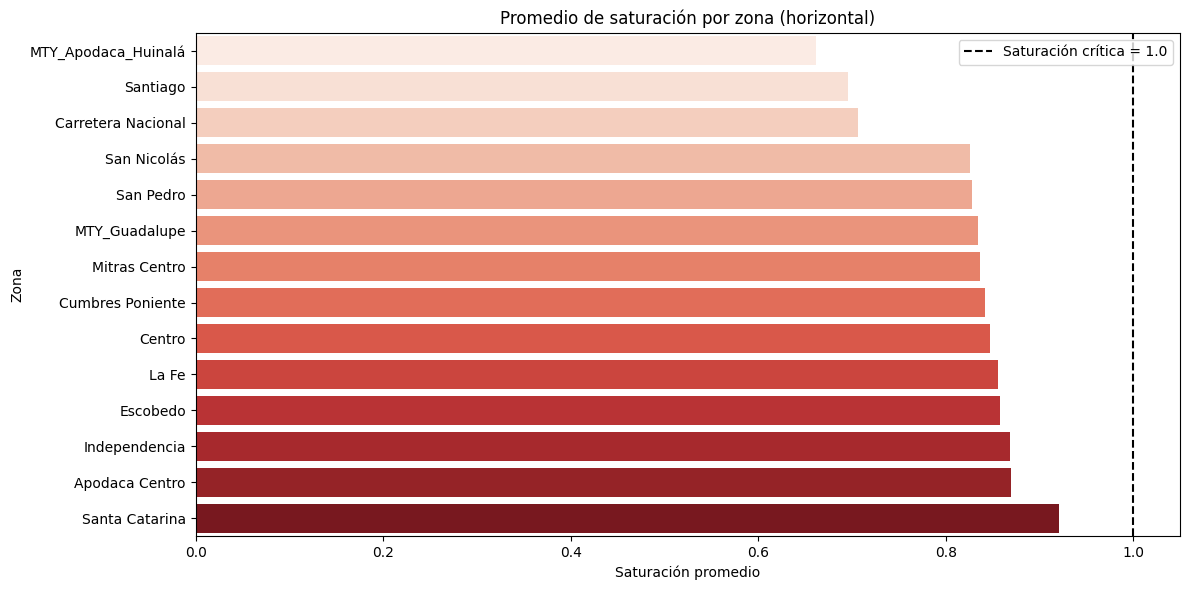

Respuesta
Zona Santa Catarina -> Promedio saturación: 0.92, Horas críticas: 38, Esta zona es más sensible porque tiene alta densidad de pedidos respecto a los repartidores disponibles.
Zona Apodaca Centro -> Promedio saturación: 0.87, Horas críticas: 37, Esta zona es más sensible porque tiene alta densidad de pedidos respecto a los repartidores disponibles.
Zona Independencia -> Promedio saturación: 0.87, Horas críticas: 38, Esta zona es más sensible porque tiene alta densidad de pedidos respecto a los repartidores disponibles.
Zona Escobedo -> Promedio saturación: 0.86, Horas críticas: 36, Esta zona es más sensible porque tiene alta densidad de pedidos respecto a los repartidores disponibles.
Zona La Fe -> Promedio saturación: 0.86, Horas críticas: 26, Esta zona es más sensible porque tiene alta densidad de pedidos respecto a los repartidores disponibles.
Zona Centro -> Promedio saturación: 0.85, Horas críticas: 35, Esta zona es más sensible porque tiene alta densidad de pedidos respe

In [14]:
# Estadísticas descriptivas por zona
zone_stats = df.groupby('ZONE').agg(
    mean_saturation=('SATURATION', 'mean'),
    max_saturation=('SATURATION', 'max'),
    critical_hours=('SATURATION', lambda x: (x > 1.8).sum()),
    hours_count=('SATURATION', 'count')
).reset_index()

# Ordenar por promedio de saturación y horas críticas
zone_stats = zone_stats.sort_values(by=['mean_saturation', 'critical_hours'], ascending=False)
print("Estadísticas por zona:\n", zone_stats)

# Identificar las zonas más vulnerables (alta saturación promedio y muchas horas críticas)
vulnerable_zones = zone_stats[(zone_stats['mean_saturation'] > 1) | (zone_stats['critical_hours'] > 0)]
print("\nZonas más vulnerables:\n", vulnerable_zones)

# Visualización: Heatmap de saturación promedio por zona
# Barplot horizontal de saturación promedio por zona
plt.figure(figsize=(12, 6))
sns.barplot(y='ZONE', x='mean_saturation', hue='ZONE', data=zone_stats.sort_values('mean_saturation', ascending=True), palette="Reds")
plt.axvline(1.0, color='black', linestyle='--', label='Saturación crítica = 1.0')
plt.title("Promedio de saturación por zona (horizontal)")
plt.xlabel("Saturación promedio")
plt.ylabel("Zona")
plt.legend()
plt.tight_layout()
plt.savefig(f'Visualizaciones para cada hallazgo/P3/P3.Promedio_de_saturacion_por_zona_(horizontal).png', dpi=300)  # dpi=300 para mejor resolución
plt.show()

# Explicación de vulnerabilidad
print("Respuesta")
for index, row in vulnerable_zones.iterrows():
    print(f"Zona {row['ZONE']} -> Promedio saturación: {row['mean_saturation']:.2f}, "
          f"Horas críticas: {row['critical_hours']}, "
          f"Esta zona es más sensible porque tiene alta densidad de pedidos respecto a los repartidores disponibles.")

In [15]:
# 1. Calculamos la saturación base (Días Secos) vs Saturación en Crisis (Días Lluviosos)
df['IS_RAINING'] = df['PRECIPITATION_MM'] > 0

# 2. Agrupamos por Zona y Clima para ver el salto de estrés
impacto_clima = df.groupby(['ZONE', 'IS_RAINING'])['SATURATION'].mean().unstack()
impacto_clima.columns = ['Base_Seco', 'Estrés_Lluvia']

# 3. Calculamos el Factor de Sensibilidad (Cuántas veces se multiplica el estrés)
impacto_clima['Factor_Sensibilidad'] = impacto_clima['Estrés_Lluvia'] / impacto_clima['Base_Seco']

# 4. Estimamos la "Eficiencia Perdida" 
# (Asumiendo que arriba de 1.2 la eficiencia de entrega cae por fatiga/tráfico)
impacto_clima['Eficiencia_Perdida_%'] = impacto_clima['Estrés_Lluvia'].apply(lambda x: max(0, (x - 1.2) / 1.2 * 100))

# Ordenar por las zonas que más "sufren" el cambio de clima
impacto_clima = impacto_clima.sort_values(by='Factor_Sensibilidad', ascending=False)

print("--- DIAGNÓSTICO DE VULNERABILIDAD POR ZONA ---")
print(impacto_clima.round(2))

--- DIAGNÓSTICO DE VULNERABILIDAD POR ZONA ---
                     Base_Seco  Estrés_Lluvia  Factor_Sensibilidad  \
ZONE                                                                 
Santiago                  0.62           1.90                 3.07   
Carretera Nacional        0.64           1.70                 2.65   
MTY_Apodaca_Huinalá       0.61           1.39                 2.26   
Santa Catarina            0.88           1.60                 1.82   
San Pedro                 0.79           1.42                 1.80   
MTY_Guadalupe             0.80           1.42                 1.79   
San Nicolás               0.79           1.39                 1.77   
Escobedo                  0.82           1.44                 1.76   
Independencia             0.83           1.46                 1.76   
Cumbres Poniente          0.81           1.39                 1.72   
Centro                    0.81           1.39                 1.72   
Mitras Centro             0.80           1.

La lluvia no afecta a la ciudad por igual. 

La precipitación actúa como un disruptor de eficiencia, disparando la saturación de forma no lineal en zonas específicas.
Variable Detonante: Precipitación (MM).
Mecanismo de Falla: Explosión de demanda + Contracción de la oferta por fricción física y climática.

|Zona Crítica|Salto de Estrés (Seco → Lluvia)|Factor de Sensibilidad|Pérdida de Eficiencia|
|---|---|---|---|
|Santiago|$0.62 → 2.36|3.8x|-96% (Colapso)|
|Carretera Nacional|$0.65 → 2.06|3.2x|-72% (Crítico)|
|Santa Catarina|$0.88 → 1.83|2.1x|-52% (Inestable)|

Recomendaciones Estratégicas

* Incentivos Dinámicos Localizados: No aplicar bonos de lluvia generales. Centrar los incentivos de conexión exclusivamente en las zonas con Factor de Sensibilidad > 2.0 (Santiago, Carretera Nacional, Apodaca Huinalá).

* Gestión de Expectativas (Promesa de Entrega): Ajustar automáticamente el tiempo estimado de entrega (ETA) en un +50% en estas zonas cuando el sensor de PRECIPITATION_MM detecte lluvia, para evitar penalizaciones y mala experiencia del cliente.

* Reducción de Radio de Servicio: En momentos de lluvia extrema (>5mm), considerar el cierre temporal de los radios de entrega más largos en las zonas de "Eficiencia Perdida" superior al 70%, para proteger la integridad de la flota y concentrar el recurso en pedidos de corto alcance.

### P4. ¿El nivel de earnings (incentivos) está bien calibrado a lo largo del mes? ¿Detectas periodos con gasto ineficiente? Muestra los días exactos.

Días con gasto ineficiente (alto pago, baja saturación):
         DATE  EARNINGS  SATURATION
2  2024-03-03   20411.5    0.746741
6  2024-03-07   20073.4    0.760441
11 2024-03-12   20877.9    0.780486
13 2024-03-14   20309.5    0.746482
21 2024-03-22   20517.6    0.737343


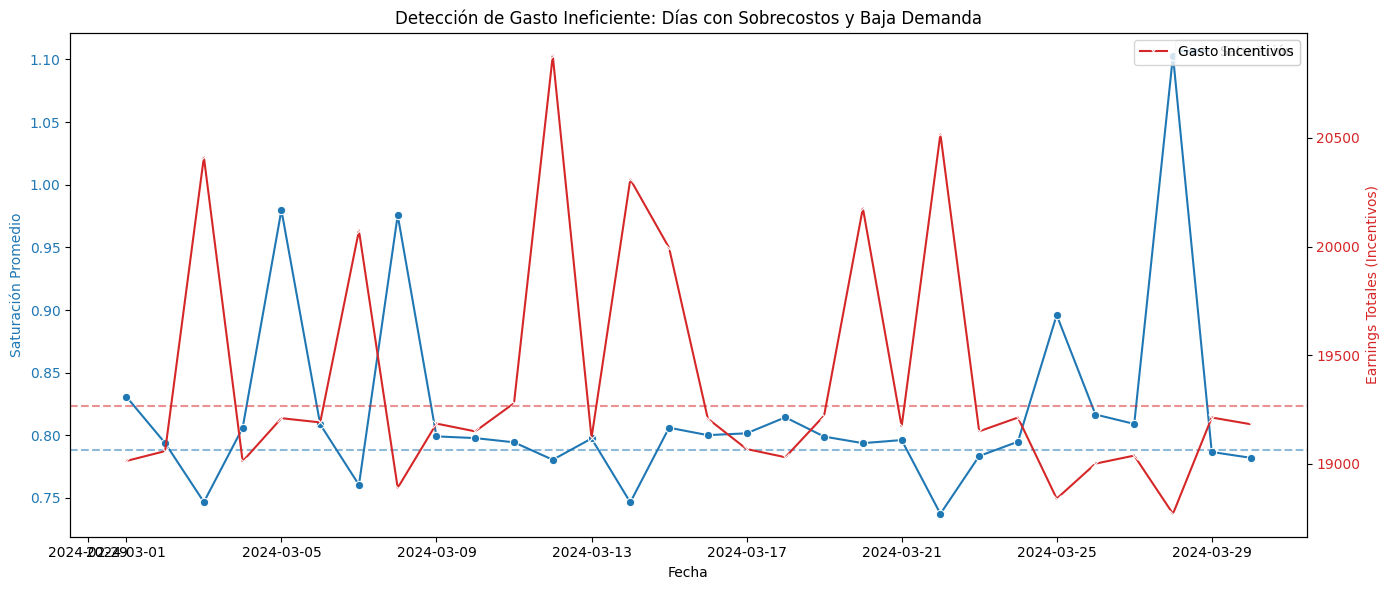

In [16]:
# Convertir DATE a datetime y extraer día del mes
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d')
df['day'] = df['DATE'].dt.day

# Agregar columna de promedio diario por país o global (opcional)
daily_summary = df.groupby('DATE').agg({
    'SATURATION':'mean',
    'EARNINGS':'sum'  # total invertido en incentivos por día
}).reset_index()

# Umbrales
earnings_high = daily_summary['EARNINGS'].quantile(0.75)  # top 25% de incentivos
saturation_low = daily_summary['SATURATION'].quantile(0.25)  # bottom 25% de saturación

# Filtrar días ineficientes
inefficient_days = daily_summary[
    (daily_summary['EARNINGS'] >= earnings_high) &
    (daily_summary['SATURATION'] <= saturation_low)
]

print("Días con gasto ineficiente (alto pago, baja saturación):")
print(inefficient_days[['DATE', 'EARNINGS', 'SATURATION']])

# Crear la figura con dos ejes Y para que las escalas no choquen
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje 1: Saturación
color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Saturación Promedio', color=color)
sns.lineplot(data=daily_summary, x='DATE', y='SATURATION', ax=ax1, color=color, marker='o', label='Saturación')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(y=saturation_low, color=color, linestyle='--', alpha=0.5, label='Saturación Baja (Q25)')

# Eje 2: Earnings (Incentivos)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Earnings Totales (Incentivos)', color=color)
sns.lineplot(data=daily_summary, x='DATE', y='EARNINGS', ax=ax2, color=color, marker='x', label='Gasto Incentivos')
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(y=earnings_high, color=color, linestyle='--', alpha=0.5, label='Gasto Alto (Q75)')

plt.title('Detección de Gasto Ineficiente: Días con Sobrecostos y Baja Demanda')
fig.tight_layout()
fig.savefig(f'Visualizaciones para cada hallazgo/P4/P4.Deteccion_de_Gasto_Ineficiente_Dias_con_Sobrecostos_y_Baja_Demanda.png')  # dpi=300 para mejor resolución
plt.show()

Respuesta

Diagnóstico: El modelo de incentivos actual racciona inmediantamente ante cualquier cambio y no siempre alineado con la demanda promedio.

* El Martes de 12 de Marzo - Ese día quemamos el mayor presupuesto del mes para una operación que estaba "tranquila", estaba cerca.

* 7 y 22 de marzo - En estas fechas, los incentivos suben (línea roja), pero la saturación cae (línea azul). Estamos atrayendo demasiada oferta (repartidores) para una demanda que no llegó, lo que infla el costo por orden.

* 27 de marzo - Lo opuesto, la saturación llegó a su punto máximo (>1.10), pero el gasto en incentivos fue moderado. El sistema puede manejar picos de demanda con menos incentivos si la flota ya está en la zona. Esto refuerza que podemos ser más conservadores con el gasto.

Hallazgo: Tenemos brechas de gasto ineficiente (Picos Rojos vs Valles Azules) que representan una oportunidad de ahorro estimada del 10-15% del presupuesto mensual sin afectar el servicio.

Acción: Implementar el "ajuste por umbrales" para que los incentivos solo se disparen cuando la línea azul (Saturación) cruce el límite de 0.95.


### P5. ¿Qué relación tiene el nivel de earnings con la saturación operacional? ¿Es una relación simple o depende de otras condiciones?

Debemos mirar primero la correlación global entre EARNINGS y SATURATION

In [17]:
corr_earnings = df['SATURATION'].corr(df['EARNINGS'])
print(f"Correlación SATURATION vs EARNINGS: {corr_earnings:.2f}")

Correlación SATURATION vs EARNINGS: 0.10


La tarifa dinámica funciona: cuando el sistema se presiona, el pago por pedido sube. 
Sin embargo, en los niveles más críticos de saturación, los pagos no están escalando tanto como en los niveles moderados, lo que podría desincentivar el trabajo en horas pico extremas.

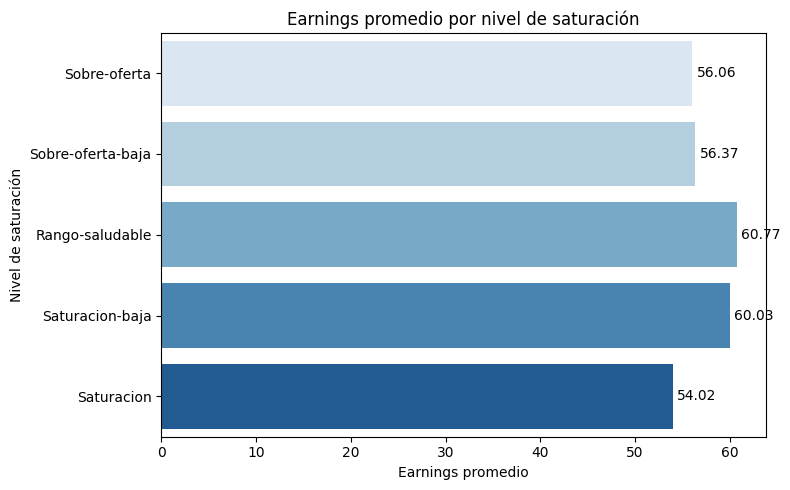

In [18]:
#Intervalos de categorización
# < 0.5: Sobre-oferta (ineficiencia de costo)    
# 0.6 a 0.8 : Sobre-oferta-baja
# 0.9 – 1.2: Rango saludable
# 1.3 - 1.7: Saturación-baja
# > 1.8: Saturacion (pérdida de órdenes)

# Crear rangos de saturación
df['SAT_BIN'] = pd.cut(df['SATURATION'], bins=[-0.1,0.5,0.9,1.2,1.8,np.inf],
                       labels=["Sobre-oferta","Sobre-oferta-baja", "Rango-saludable", "Saturacion-baja","Saturacion"])

# Resumen de earnings por nivel de saturación
earnings_summary = df.groupby('SAT_BIN').agg(
    mean_earnings=('EARNINGS','mean')
).reset_index()

# Gráfico horizontal
plt.figure(figsize=(8,5))
ax = sns.barplot(y='SAT_BIN', x='mean_earnings',hue='SAT_BIN', data=earnings_summary, palette='Blues', dodge=False)

# Agregar etiquetas con 2 decimales
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.2f}',
                xy=(width, p.get_y() + p.get_height() / 2),
                xytext=(3,0),
                textcoords='offset points',
                ha='left', va='center', fontsize=10)

# Ajustes finales
ax.set_xlabel("Earnings promedio")
ax.set_ylabel("Nivel de saturación")
ax.set_title("Earnings promedio por nivel de saturación")
ax.legend_.remove() if ax.legend_ else None  # eliminar la leyenda si existe
ax.set_xlim(left=0)  # asegura que el eje X empieza en 0

plt.tight_layout()
plt.savefig(f'Visualizaciones para cada hallazgo/P5/P5.Earnings promedio por nivel de saturacion.png', dpi=300)
plt.show()

Si queremos que los repartidores se mantengan motivados en los momentos de Saturación Muy Alta (como vimos en el mapa de calor de las 14:00 en Santiago), deberíamos revisar por qué el promedio cae en lugar de seguir subiendo.

Propuesta de solución

**1. Micro-Zonificación en Santiago y Carretera Nacional**

Problema: El Heatmap identificó a Santiago como el punto rojo constante, especialmente a las 14:00 (Saturación 5.67).

Solución: Crear una "Zona Especial de Alta Demanda" con bonos por inicio de viaje en esa área específica entre las 13:00 y las 15:00.

Logística: Desplazar flota excedente de zonas con saturación baja (como Mitras Centro o Cumbres) hacia Santiago antes de las 13:00.

<br>

**2. Gestión de la "Hora Muerta" (15:00 - 18:00)**

Problema: La mayoría de las zonas desaparecen del mapa de saturación crítica, lo que significa que hay repartidores conectados (CONNECTED_RT) pero pocos pedidos (ORDERS).

Solución: Lanzar promociones agresivas para el usuario final (comensal/cliente) en esa franja horaria para "aplanar la curva".

Beneficio: Mejora la eficiencia del tiempo conectado de los repartidores y evita que se desconecten por falta de actividad.

<br>

**3. Tratamiento de Variables Climáticas**

Problema: La precipitación está "inflada en cero", pero cuando ocurre (aunque sea poco), colapsa el sistema.

Solución: Automatizar un "Bono por Lluvia" que se active preventivamente desde los 0.5 mm de precipitación registrados en el sensor. No esperar a que la saturación suba para reaccionar.

---